#### Setup

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import pickle

with open('../data/processed/verified_logistics_graph.pkl', 'rb') as f:
    G = pickle.load(f)

print("Monte Carlo Risk Engine Initialized.")

Monte Carlo Risk Engine Initialized.


#### Defining the Shock Variables

In [2]:
ITERATIONS = 1000
BASE_EXPORT_PRICE = 8.50
BASE_LOGISTICS_COST = 1.65
ELASTICITY = 0.72

results = []

for _ in range(ITERATIONS):
    # 1. Fuel Shock (Normal Distribution)
    fuel_multiplier = np.random.normal(1.0, 0.15) 
    transport_cost = BASE_LOGISTICS_COST * fuel_multiplier
    
    # 2. Informal Extraction (Uniform Distribution - "The Leak")
    informal_leak = np.random.uniform(0.05, 0.30)
    
    # 3. Calculate Simulated Farmgate
    sim_farmgate = (BASE_EXPORT_PRICE * ELASTICITY) - transport_cost - informal_leak
    
    # 4. Calculate Farmer Share
    sim_share = (sim_farmgate / BASE_EXPORT_PRICE) * 100
    
    results.append({
        'farmgate_price': sim_farmgate,
        'farmer_share': sim_share,
        'transport_cost': transport_cost,
        'leakage': informal_leak
    })

sim_df = pd.DataFrame(results)
print(f"Simulation Complete: {ITERATIONS} scenarios modeled.")

Simulation Complete: 1000 scenarios modeled.


#### Visualizing the Value at Risk

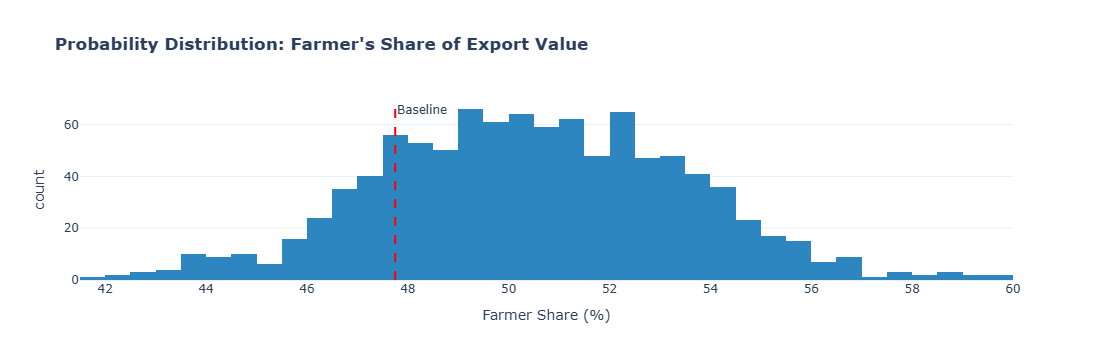

In [4]:
fig = px.histogram(sim_df, x="farmer_share", 
                   title="<b>Probability Distribution: Farmer's Share of Export Value</b>",
                   labels={'farmer_share': 'Farmer Share (%)'},
                   nbins=50,
                   color_discrete_sequence=['#2E86C1'])

# Add a vertical line for 47.75% baseline
fig.add_vline(x=47.75, line_dash="dash", line_color="red", 
              annotation_text="Baseline")

fig.update_layout(template="plotly_white", showlegend=False)
fig.show()

#### Identifying the Critical Leak (Sensitivity Analysis)

In [8]:
correlation = sim_df.corr()['farmer_share'].sort_values()
print("Sensitivity Analysis (Correlation with Farmer Income):")
print(correlation)

Sensitivity Analysis (Correlation with Farmer Income):
transport_cost   -0.959765
leakage          -0.301049
farmer_share      1.000000
farmgate_price    1.000000
Name: farmer_share, dtype: float64


#### Saving the Risk Profile

In [6]:
sim_df.to_csv('../data/processed/monte_carlo_risk_results.csv', index=False)
print("Risk profile saved for the Dashboard.")

Risk profile saved for the Dashboard.


In [7]:
sim_df.head()

,farmgate_price,farmer_share,transport_cost,leakage
0,4.309713,50.702505,1.634790,0.175497
1,4.191582,49.312732,1.714309,0.214109
2,4.674732,54.996848,1.148682,0.296586
3,4.560877,53.657380,1.492188,0.066934
4,4.176263,49.132502,1.772158,0.171580
